# Checkpoint 1 
## (Do not remove any comments that start with"# @@@".) 

Reminder: 

- You are being evaluated for completion and effort in this checkpoint. 
- Avoid manual labor / hard coding as much as possible, everything we've taught you so far are meant to simplify and automate your process.
- Please do not remove any comment that starts with: "# @@@". 

We will be working with the same `states_edu.csv` that you should already be familiar with from the tutorial.

We investigated Grade 8 reading score in the tutorial. For this checkpoint, you are asked to investigate another test. Here's an overview:

* Choose a specific response variable to focus on
>Grade 4 Math, Grade 4 Reading, Grade 8 Math
* Pick or create features to use
>Will all the features be useful in predicting test score? Are some more important than others? Should you standardize, bin, or scale the data?
* Explore the data as it relates to that test
>Create at least 2 visualizations (graphs), each with a caption describing the graph and what it tells us about the data
* Create training and testing data
>Do you want to train on all the data? Only data from the last 10 years? Only Michigan data?
* Train a ML model to predict outcome 
>Define what you want to predict, and pick a model in sklearn to use (see sklearn <a href="https://scikit-learn.org/stable/modules/linear_model.html">regressors</a>).


Include comments throughout your code! Every cleanup and preprocessing task should be documented.


<h2> Data Cleanup </h2>

Import `numpy`, `pandas`, and `matplotlib`.

(Feel free to import other libraries!)

In [53]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Load in the "states_edu.csv" dataset and take a look at the head of the data

In [54]:
df = pd.read_csv("../data/states_edu.csv")
df.head()

,PRIMARY_KEY,STATE,YEAR,ENROLL,TOTAL_REVENUE,FEDERAL_REVENUE,STATE_REVENUE,LOCAL_REVENUE,TOTAL_EXPENDITURE,INSTRUCTION_EXPENDITURE,...,GRADES_4_G,GRADES_8_G,GRADES_12_G,GRADES_1_8_G,GRADES_9_12_G,GRADES_ALL_G,AVG_MATH_4_SCORE,AVG_MATH_8_SCORE,AVG_READING_4_SCORE,AVG_READING_8_SCORE
0,1992_ALABAMA,ALABAMA,1992,NaN,2678885.0,304177.0,1659028.0,715680.0,2653798.0,1481703.0,...,57948.0,58025.0,41167.0,NaN,NaN,731634.0,208.0,252.0,207.0,NaN
1,1992_ALASKA,ALASKA,1992,NaN,1049591.0,106780.0,720711.0,222100.0,972488.0,498362.0,...,9748.0,8789.0,6714.0,NaN,NaN,122487.0,NaN,NaN,NaN,NaN
2,1992_ARIZONA,ARIZONA,1992,NaN,3258079.0,297888.0,1369815.0,1590376.0,3401580.0,1435908.0,...,55433.0,49081.0,37410.0,NaN,NaN,673477.0,215.0,265.0,209.0,NaN
3,1992_ARKANSAS,ARKANSAS,1992,NaN,1711959.0,178571.0,958785.0,574603.0,1743022.0,964323.0,...,34632.0,36011.0,27651.0,NaN,NaN,441490.0,210.0,256.0,211.0,NaN
4,1992_CALIFORNIA,CALIFORNIA,1992,NaN,26260025.0,2072470.0,16546514.0,7641041.0,27138832.0,14358922.0,...,418418.0,363296.0,270675.0,NaN,NaN,5254844.0,208.0,261.0,202.0,NaN


You should always familiarize yourself with what each column in the dataframe represents. Read about the states_edu dataset here: https://www.kaggle.com/noriuk/us-education-datasets-unification-project

Use this space to rename columns, deal with missing data, etc. _(optional)_

In [55]:
target = "AVG_MATH_4_SCORE"

numeric_columns = [
    "YEAR", "ENROLL", "TOTAL_EXPENDITURE", target
]

for column in numeric_columns:
    df[column] = pd.to_numeric(df[column], errors="coerce")

df["STATE"] = df["STATE"].str.strip().str.upper()

<h2>Exploratory Data Analysis (EDA) </h2>

Chosen one of Grade 4 Reading, Grade 4 Math, or Grade 8 Math to focus on: *I chose Grade 4 Math, represented by AVG_MATH_4_SCORE.*

How many years of data are logged in our dataset? 

In [56]:
# @@@ 1
# Your Code
df["YEAR"].nunique()

33

Let's compare Michigan to Ohio. Which state has the higher average across all years in the test you chose?

In [57]:
# @@@ 2
state_averages = (
    df.loc[df["STATE"].isin(["MICHIGAN", "OHIO"])]
    .groupby("STATE")[target]
    .mean()
)

print(state_averages)
print("Higher average:", state_averages.idxmax())

STATE
MICHIGAN    234.363636
OHIO        239.454545
Name: AVG_MATH_4_SCORE, dtype: float64
Higher average: OHIO


Find the average for your chosen test across all states in 2019

In [58]:
# @@@ 3
df.loc[df["YEAR"] == 2019, target].mean()


np.float64(239.9433962264151)

For each state, find a maximum value for your chosen test score

In [59]:
# @@@ 4
df.groupby("STATE")[target].max()


STATE
ALABAMA                 233.0
ALASKA                  237.0
ARIZONA                 240.0
ARKANSAS                240.0
CALIFORNIA              235.0
COLORADO                247.0
CONNECTICUT             245.0
DELAWARE                243.0
DISTRICT_OF_COLUMBIA    235.0
DODEA                   250.0
FLORIDA                 246.0
GEORGIA                 240.0
HAWAII                  243.0
IDAHO                   242.0
ILLINOIS                239.0
INDIANA                 249.0
IOWA                    246.0
KANSAS                  248.0
KENTUCKY                242.0
LOUISIANA               234.0
MAINE                   246.0
MARYLAND                247.0
MASSACHUSETTS           253.0
MICHIGAN                238.0
MINNESOTA               253.0
MISSISSIPPI             241.0
MISSOURI                241.0
MONTANA                 244.0
NATIONAL                242.0
NEBRASKA                246.0
NEVADA                  237.0
NEW_HAMPSHIRE           253.0
NEW_JERSEY              249.0
NEW_

*Refer to the `Grouping and Aggregating` section in Tutorial 0 if you are stuck.

<h2> Feature Engineering </h2>

After exploring the data, you can choose to modify features that you would use to predict the performance of the students on your chosen response variable. 

You can also create your own features. For example, perhaps you figured that maybe a state's expenditure per student may affect their overall academic performance so you create a expenditure_per_student feature.

Use this space to modify or create features.

In [60]:
# @@@ 5
valid_enrollment = df["ENROLL"].where(df["ENROLL"] > 0)

df["EXPENDITURE_PER_STUDENT"] = (
    df["TOTAL_EXPENDITURE"] / valid_enrollment
)

df["EXPENDITURE_PER_STUDENT"] = (
    df["EXPENDITURE_PER_STUDENT"]
    .replace([np.inf, -np.inf], np.nan)
)

features = ["EXPENDITURE_PER_STUDENT", "YEAR"]


Feature engineering justification: **<BRIEFLY DESCRIBE WHY YOU MADE THE CHANGES THAT YOU DID\>**

<h2>Visualization</h2>

Investigate the relationship between your chosen response variable and at least two predictors using visualizations. Write down your observations.

**Visualization 1**

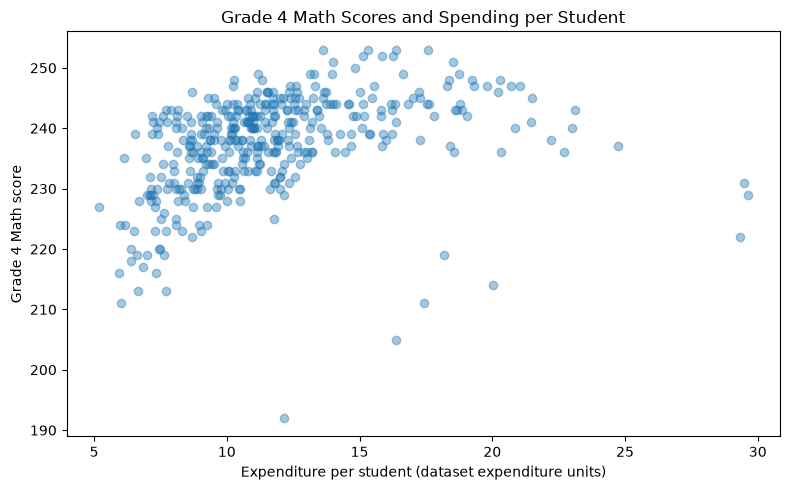

In [61]:
# @@@ 6
plot_data = df.dropna(subset=["EXPENDITURE_PER_STUDENT", target])

plt.figure(figsize=(8, 5))
plt.scatter(
    plot_data["EXPENDITURE_PER_STUDENT"],
    plot_data[target],
    alpha=0.4,
)
plt.xlabel("Expenditure per student (dataset expenditure units)")
plt.ylabel("Grade 4 Math score")
plt.title("Grade 4 Math Scores and Spending per Student")
plt.tight_layout()
plt.show()

**Each point represents a state-year observation with both values available. Spending per student has a modest positive association with Grade 4 Math scores, but the substantial scatter indicates that spending alone cannot explain performance. This association does not establish causation.**

**Visualization 2**

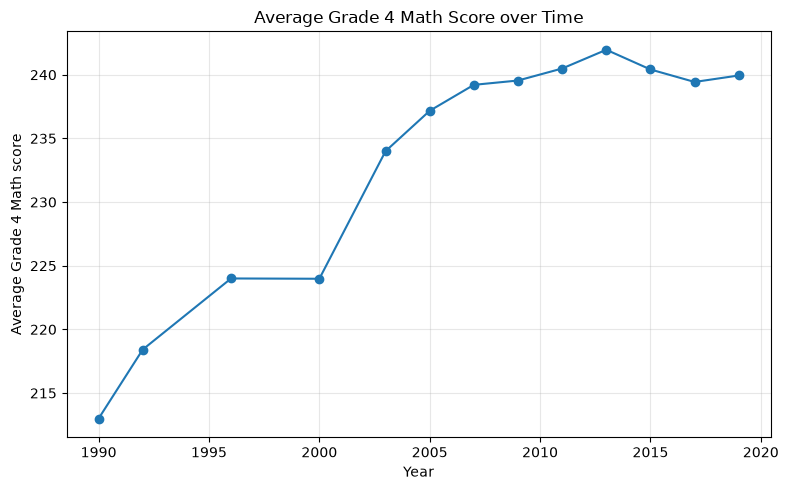

In [62]:
# @@@ 7
yearly_scores = df.groupby("YEAR")[target].mean().dropna()

plt.figure(figsize=(8, 5))
plt.plot(yearly_scores.index, yearly_scores.values, marker="o")
plt.xlabel("Year")
plt.ylabel("Average Grade 4 Math score")
plt.title("Average Grade 4 Math Score over Time")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**The graph shows the unweighted average of available Grade 4 Math scores for each year. Scores generally increase over the observed period, supporting the inclusion of year as a predictor. The states with available scores may differ across years, and this average is not weighted by student population.**

<h2> Data Creation </h2>

_Use this space to create train/test data_

In [63]:
from sklearn.model_selection import train_test_split

In [64]:
# @@@ 8
# Supervised training requires an observed target. I made lots of mistakes on this.
model_data = df.dropna(subset=[target]).copy()

X = model_data[features]
y = model_data[target]

In [65]:
# @@@ 9 

# X_train, X_test, y_train, y_test = train_test_split(
#      X, y, test_size=, random_state=42)
from sklearn.model_selection import train_test_split

# Hold out 20% of state-year observations for evaluation.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
)

<h2> Prediction </h2>

ML Models [Resource](https://medium.com/@vijaya.beeravalli/comparison-of-machine-learning-classification-models-for-credit-card-default-data-c3cf805c9a5a)

In [66]:
# @@@ 10
# import your sklearn class here
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge

In [67]:
# @@@ 11
# create your model here
# The pipeline learns imputation and scaling from training data only.
model = make_pipeline(
    SimpleImputer(strategy="median"),
    StandardScaler(),
    Ridge(alpha=1.0),
)

In [68]:
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('simpleimputer', ...), ('standardscaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](2,)","['EXPENDITURE_PER_STUDENT','YEAR']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,2
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool

In [69]:
y_pred = model.predict(X_test)

## Evaluation

Choose some metrics to evaluate the performance of your model, some of them are mentioned in the tutorial.

In [70]:
# @@@ 12
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)

print(f"MAE: {mean_absolute_error(y_test, y_pred):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")
print(f"R²: {r2_score(y_test, y_pred):.3f}")

# Compare against always predicting the training-set mean.
baseline_pred = np.full(len(y_test), y_train.mean())

print(
    f"Baseline MAE: "
    f"{mean_absolute_error(y_test, baseline_pred):.2f}"
)

MAE: 5.10
RMSE: 6.15
R²: 0.572
Baseline MAE: 7.27


We have copied over the graphs that visualize the model's performance on the training and testing set. 

Change `col_name` and modify the call to `plt.ylabel()` to isolate how a single predictor affects the model.

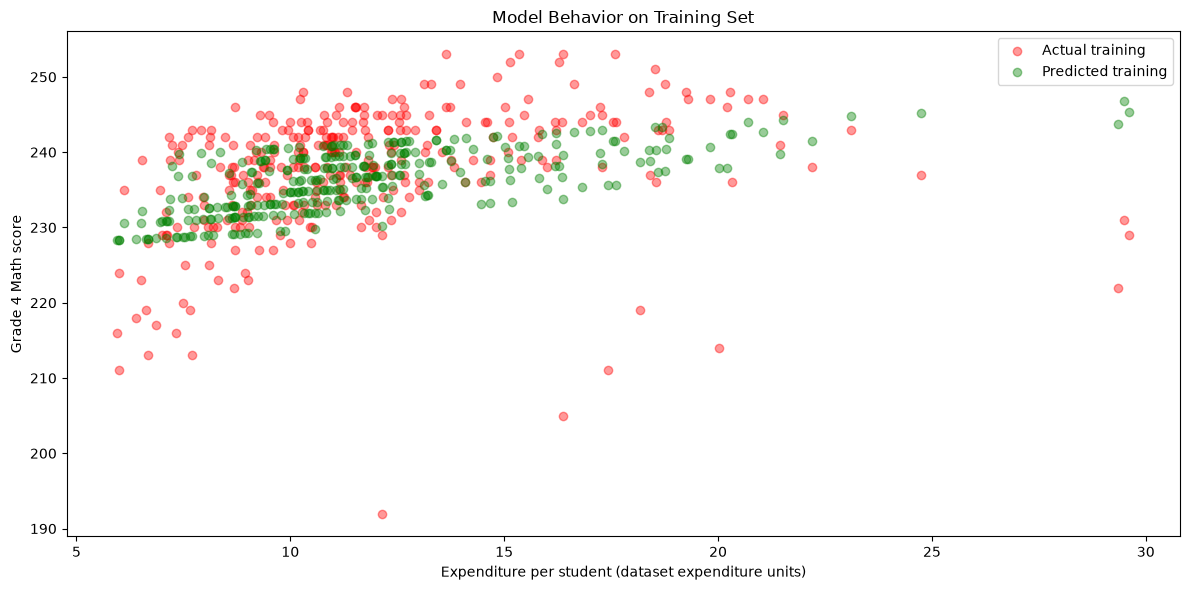

In [71]:
# @@@ 13
col_name = "EXPENDITURE_PER_STUDENT"

plt.figure(figsize=(12, 6))
plt.scatter(
    X_train[col_name], y_train,
    color="red", alpha=0.4, label="Actual training",
)
plt.scatter(
    X_train[col_name], model.predict(X_train),
    color="green", alpha=0.4, label="Predicted training",
)
plt.xlabel("Expenditure per student (dataset expenditure units)")
plt.ylabel("Grade 4 Math score")
plt.title("Model Behavior on Training Set")
plt.legend()
plt.tight_layout()
plt.show()

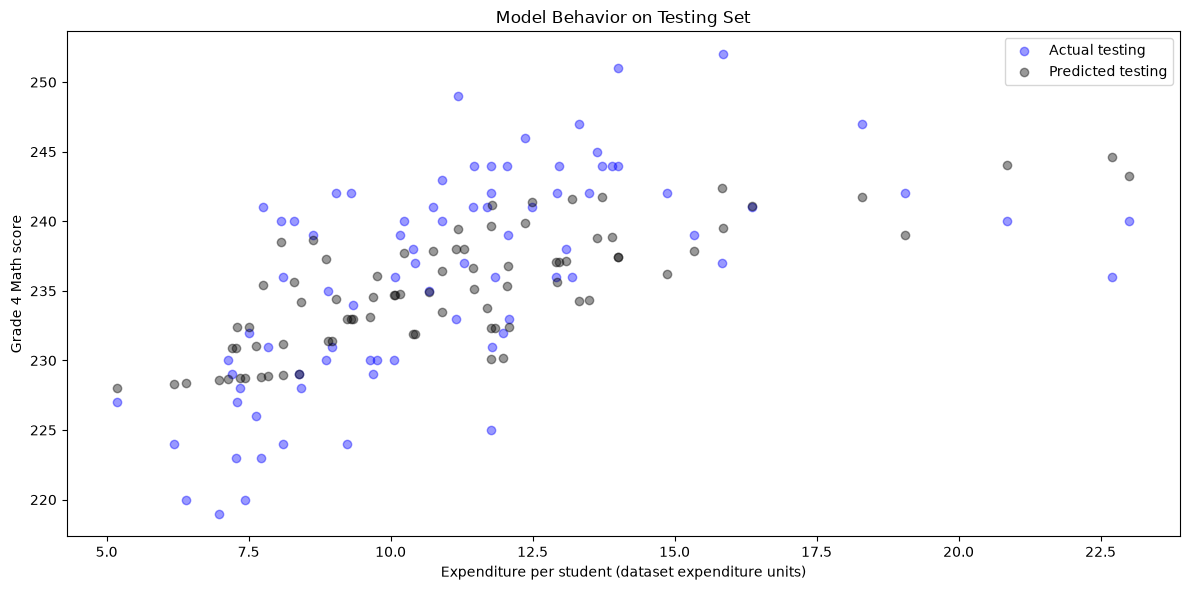

In [72]:
# @@@ 14
col_name = "EXPENDITURE_PER_STUDENT"

plt.figure(figsize=(12, 6))
plt.scatter(
    X_test[col_name], y_test,
    color="blue", alpha=0.4, label="Actual testing",
)
plt.scatter(
    X_test[col_name], y_pred,
    color="black", alpha=0.4, label="Predicted testing",
)
plt.xlabel("Expenditure per student (dataset expenditure units)")
plt.ylabel("Grade 4 Math score")
plt.title("Model Behavior on Testing Set")
plt.legend()
plt.tight_layout()
plt.show()